In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout, Reshape, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
tf.keras.preprocessing.sequence.TimeseriesGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LeakyReLU
tf.keras.callbacks.EarlyStopping
from sklearn.metrics import mean_absolute_error,mean_squared_error
mpl.rcParams['figure.figsize']= (20,10)
mpl.rcParams['axes.grid']= False

In [ ]:
load_data = pd.read_csv('/content/final data 1 day_f.csv')

In [ ]:
load_data["Date"] = pd.to_datetime(load_data["Date"], dayfirst=True)
load_data['Year']=load_data['Date'].dt.year
load_data['Month']=load_data['Date'].dt.month
load_data['Day']=load_data['Date'].dt.day

In [ ]:
df=load_data[['NLDC Demand','temparature_C','Humidity','Day','Month','Year']]

In [ ]:
# Drop all rows where 'NLDC Demand' column has value 0
df = df[df['NLDC Demand'] != 0]

# Reset the index (optional, if you want to clean up the index after dropping rows)
df.reset_index(drop=True, inplace=True)

In [ ]:
df = df.dropna(axis=0)

In [ ]:
df.shape


(1791, 6)

In [ ]:
df.tail()


,NLDC Demand,temparature_C,Humidity,Day,Month,Year
1790,268.7083333,17.962500,87.732500,27,12,2022
1791,269.8333333,16.687500,79.622083,28,12,2022
1792,256.2083333,16.185417,77.284167,29,12,2022
1793,255.0416667,15.766250,77.992083,30,12,2022
1794,262.6666667,15.965417,80.560000,31,12,2022


In [ ]:
print(df['NLDC Demand'].dtype)

object


In [ ]:
df['NLDC Demand'] = pd.to_numeric(df['NLDC Demand'], errors='coerce')

In [ ]:
print(df['NLDC Demand'].dtype)

float64


In [ ]:
# Drop all rows where 'NLDC Demand' column has value 0
df = df[df['NLDC Demand'] != 0]

# Reset the index (optional, if you want to clean up the index after dropping rows)
df.reset_index(drop=True, inplace=True)

In [ ]:
df = df.dropna(axis=0)

In [ ]:
Q1 = np.percentile(df['NLDC Demand'], 25)
Q3 = np.percentile(df['NLDC Demand'], 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['NLDC Demand'] < lower_bound) | (df['NLDC Demand'] > upper_bound)]
print(outliers)


Empty DataFrame
Columns: [NLDC Demand, temparature_C, Humidity, Day, Month, Year]
Index: []


In [ ]:
# Replace outliers below lower bound with the lower bound
df['NLDC Demand'] = np.where(df['NLDC Demand'] < lower_bound, lower_bound, df['NLDC Demand'])

# Replace outliers above upper bound with the upper bound
df['NLDC Demand'] = np.where(df['NLDC Demand'] > upper_bound, upper_bound, df['NLDC Demand'])

print(df)


      NLDC Demand  temparature_C   Humidity  Day  Month  Year
0      190.260870      19.714348  82.386087    1      1  2018
1      178.875000      18.730833  83.225417    2      1  2018
2      181.583333      17.396250  85.495417    3      1  2018
3      183.291667      16.476250  82.722083    4      1  2018
4      174.000000      16.532083  81.930417    5      1  2018
...           ...            ...        ...  ...    ...   ...
1757   268.708333      17.962500  87.732500   27     12  2022
1758   269.833333      16.687500  79.622083   28     12  2022
1759   256.208333      16.185417  77.284167   29     12  2022
1760   255.041667      15.766250  77.992083   30     12  2022
1761   262.666667      15.965417  80.560000   31     12  2022

[1762 rows x 6 columns]


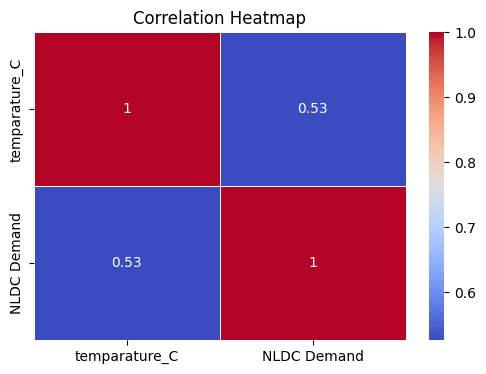

In [ ]:
# correlation between temparature and demand
corr = df[['temparature_C', 'NLDC Demand']].corr()
# Plot the heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


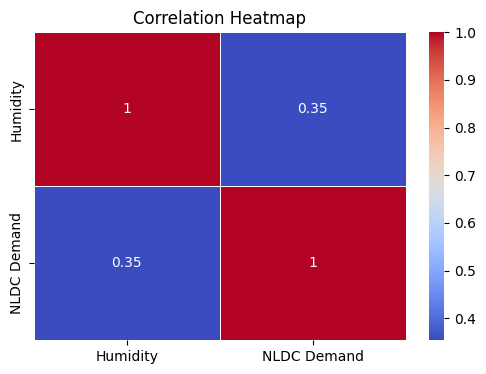

In [ ]:
#correlation between humidity and demand
corr = df[['Humidity', 'NLDC Demand']].corr()
# Plot the heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


In [ ]:
scaler=MinMaxScaler()
input_scaled= scaler.fit_transform(df)


In [ ]:
import joblib
from sklearn.preprocessing import MinMaxScaler

# Assuming 'df' is your full dataset and you have already scaled it
scaler = MinMaxScaler()

# Fit and transform your data (like you did during training)
input_scaled = scaler.fit_transform(df)

# Save the scaler for future use
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
from google.colab import drive
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Save the scaler file to Google Drive
shutil.copy('scaler.pkl', '/content/drive/My Drive/')


Mounted at /content/drive


'/content/drive/My Drive/scaler.pkl'

In [ ]:
df.shape


(1758, 6)

In [ ]:
train_size= 1230
val_size= 263
test_size= 265

In [ ]:
train_data= input_scaled[:train_size]
train_data.shape


(1230, 6)

In [ ]:
val_data= input_scaled[train_size:train_size+val_size]
val_data.shape


(263, 6)

In [ ]:
test_data= input_scaled[train_size+val_size:train_size + val_size+test_size]
test_data.shape


(265, 6)

In [ ]:
def create_sequence(data, input_length):
    X = []
    Y = []
    for i in range(len(data) - input_length):
        X.append(data[i:i + input_length, :])  # Use all features
        Y.append(data[i + input_length, 0])    # Predict the next 'NLDC Demand' value (first column)
    return np.array(X), np.array(Y)

In [ ]:
input_length=1
# Create sequences for train, validation, and test data
x_train, y_train = create_sequence(train_data, input_length)
x_val, y_val = create_sequence(val_data, input_length)
x_test, y_test = create_sequence(test_data, input_length)

# Reshape x_train, x_val, and x_test to 3D for LSTM
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], x_train.shape[2]))
x_val = np.reshape(x_val, (x_val.shape[0], x_val.shape[1], x_val.shape[2]))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], x_test.shape[2]))
print(x_train.shape, x_val.shape, x_test.shape)  # Verify the shapes are 3D


(1229, 1, 6) (262, 1, 6) (264, 1, 6)


In [ ]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.1 MB/s eta 0:00:00


In [ ]:
pip install scikeras

In [ ]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam


In [ ]:
def create_model(units=30, activation='tanh', learning_rate=0.001, dropout_rate=0.2, l2_reg=0.01):
    model = Sequential()
    # Add Input layer
    model.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
    # Add LSTM layer with kernel regularization and dropout
    model.add(LSTM(
        units=units,
        activation=activation,
        kernel_regularizer=l2(l2_reg)  # Add L2 regularization
    ))
    # Add Dropout layer
    model.add(Dropout(dropout_rate))
    # Output layer
    model.add(Dense(1))
    # Compile the model
    model.compile(
        loss='mean_squared_error',
        optimizer=Adam(learning_rate=learning_rate),
        metrics=['mean_squared_error']
    )
    return model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Stop if no improvement for 5 epochs
    restore_best_weights=True
)

# Wrap the model using KerasRegressor
regressor = KerasRegressor(model=create_model, verbose=0)

# Update the parameter grid to include dropout rate and L2 regularization
param_grid = {
    "model__units": [30, 40, 50],
    "model__activation": ['tanh', 'relu'],
    "model__learning_rate": [0.001, 0.0001],
    "model__dropout_rate": [0.2, 0.3],  # Dropout rates to try
    "model__l2_reg": [0.01, 0.001],     # L2 regularization values to try
    "batch_size": [16, 32],
    "epochs": [20]
}

In [ ]:
# Perform GridSearchCV with EarlyStopping as a fit parameter
grid = GridSearchCV(
    estimator=regressor,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1
)

# Pass EarlyStopping as a fit parameter
fit_params = {"callbacks": [early_stopping]}
grid_result = grid.fit(x_train, y_train, **fit_params)

# Display the best parameters and score
print(f"Best Parameters: {grid_result.best_params_}")
print(f"Best Score: {grid_result.best_score_}")

# Use the best model for evaluation
best_model = grid_result.best_estimator_
test_loss = best_model.score(x_test, y_test)
print(f"Test Loss: {test_loss}")


Fitting 3 folds for each of 96 candidates, totalling 288 fits
Best Parameters: {'batch_size': 16, 'epochs': 20, 'model__activation': 'tanh', 'model__dropout_rate': 0.3, 'model__l2_reg': 0.001, 'model__learning_rate': 0.001, 'model__units': 50}
Best Score: -0.003777965495408552
Test Loss: 0.818318996203595


In [ ]:
print(grid.best_params_)

{'batch_size': 16, 'epochs': 20, 'model__activation': 'tanh', 'model__dropout_rate': 0.3, 'model__l2_reg': 0.001, 'model__learning_rate': 0.001, 'model__units': 50}


In [ ]:
best_model = grid_result.best_estimator_

In [ ]:
test_loss = best_model.score(x_test, y_test)
print(f"Test Loss: {test_loss}")

Test Loss: 0.818318996203595


In [ ]:
best_params = grid_result.best_params_

In [ ]:
model = create_model(
    units=best_params["model__units"],
    activation=best_params["model__activation"],
    learning_rate=best_params["model__learning_rate"],
    dropout_rate=best_params["model__dropout_rate"],
    l2_reg=best_params["model__l2_reg"]
)

In [ ]:
# Train the model on the entire training data
history = model.fit(
    x_train, y_train,
    batch_size=best_params["batch_size"],
    epochs=best_params["epochs"],
    validation_data=(x_val, y_val),
    callbacks=[early_stopping]
)

Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.1147 - mean_squared_error: 0.1043 - val_loss: 0.0221 - val_mean_squared_error: 0.0145
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0214 - mean_squared_error: 0.0145 - val_loss: 0.0157 - val_mean_squared_error: 0.0104
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0161 - mean_squared_error: 0.0111 - val_loss: 0.0119 - val_mean_squared_error: 0.0075
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0132 - mean_squared_error: 0.0090 - val_loss: 0.0097 - val_mean_squared_error: 0.0058
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0116 - mean_squared_error: 0.0079 - val_loss: 0.0083 - val_mean_squared_error: 0.0047
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0121 - mean_squared_error: 0.0086 - val_loss: 0.0072 - val_mean_squared_error: 0.0040
Epoch 7/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0103 - mean_squared_error: 0.0071 - val_loss: 0.0067 - val_mean

In [ ]:
model.evaluate(x_test,y_test, verbose=0)
prediction=model.predict(x_test)
prediction.shape

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


(264, 1)

In [ ]:
data_step1 = x_test[:,0,:]  #select all rows. the first step (0), and all features
selected_data = prediction[:,0]


In [ ]:
df1 = pd.DataFrame(data_step1)
df2 = pd.DataFrame(selected_data)

In [ ]:
df_predicted = pd.concat([ df2,df1.iloc[:, 1:]],axis=1)
df_predicted.shape

(264, 6)

In [ ]:
r_trans = scaler.inverse_transform(df_predicted)
df_final=df[data_step1.shape[0]*-1:]
df_final['load_predicted']=r_trans[:,0]
df_final['Date']=load_data.loc[1500:1758, 'Date']

<ipython-input-45-74afe487a981>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['load_predicted']=r_trans[:,0]
<ipython-input-45-74afe487a981>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Date']=load_data.loc[1500:1758, 'Date']


In [ ]:
print(df_final['Date'].dtype)


datetime64[ns]


In [ ]:
print(df_final['Date'].isna().sum())


5


In [ ]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
print(df_final.iloc[:,[7, 0,6]])


           Date  NLDC Demand  load_predicted
1498        NaT   393.250000      354.654363
1499        NaT   428.125000      395.378919
1500 2022-03-12   370.625000      421.800142
1501 2022-03-13   387.958333      379.154228
1502 2022-03-14   338.958333      392.019486
1503 2022-03-15   366.333333      356.020548
1504 2022-03-16   359.958333      375.190692
1505 2022-03-17   403.666667      368.725789
1506 2022-03-18   293.666667      402.259838
1507 2022-03-19   367.958333      318.449649
1508 2022-03-20   388.791667      369.547893
1509 2022-03-21   422.791667      388.218553
1510 2022-03-22   400.125000      414.345583
1511 2022-03-23   375.708333      400.106800
1512 2022-03-24   412.041667      381.155691
1513 2022-03-25   289.125000      408.341162
1514 2022-03-26   445.625000      316.408796
1515 2022-03-27   494.041667      432.137157
1516 2022-03-28   307.458333      467.427050
1517 2022-03-29   339.500000      328.057892
1518 2022-03-30   305.208333      359.036599
1519 2022-

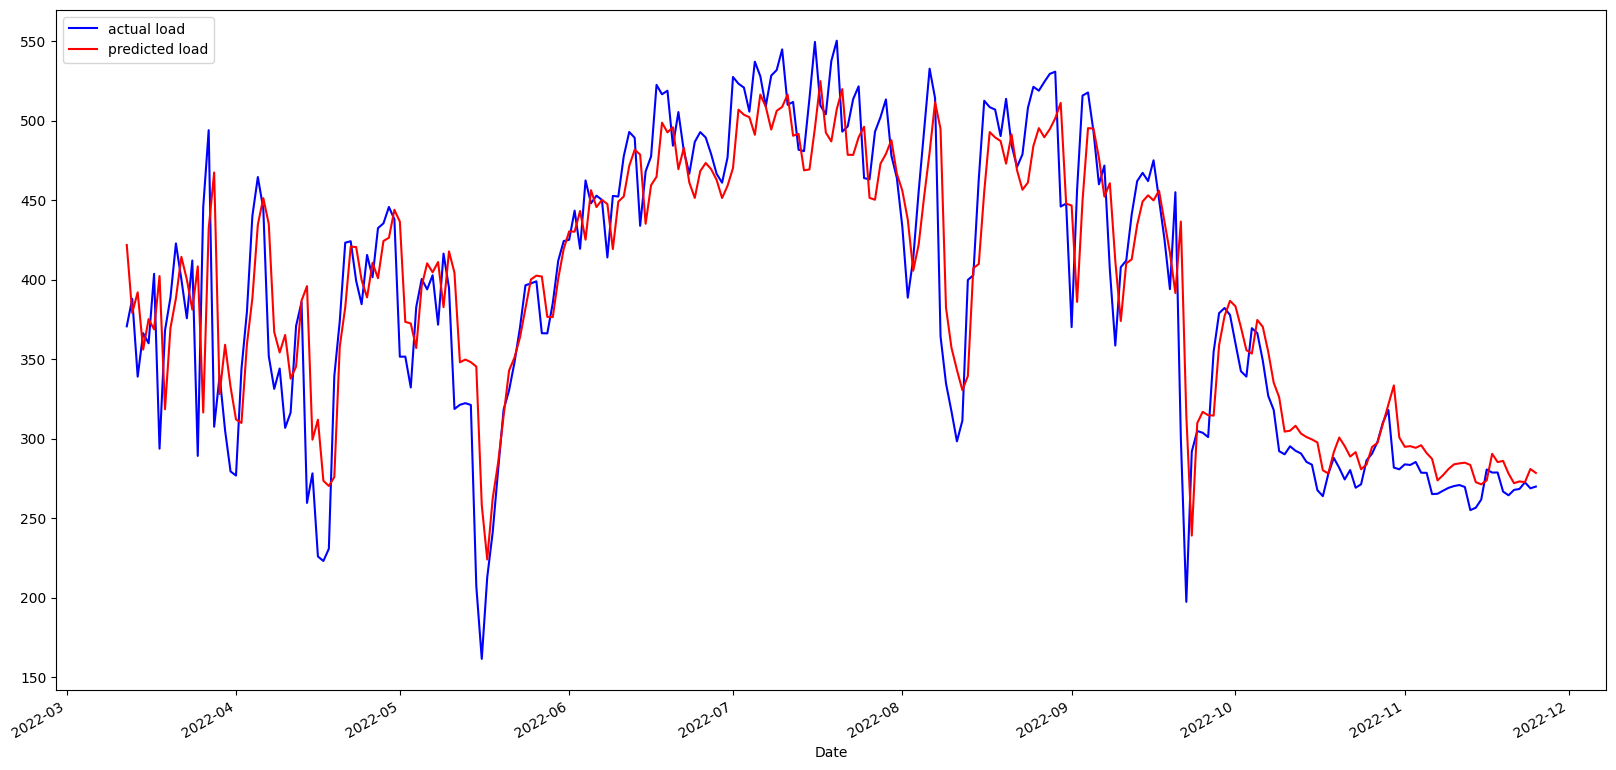

In [ ]:
fig,ax = plt.subplots(figsize=(20,10))
# plot the 'total load' in blue
df_final.plot(x= 'Date', y='NLDC Demand', ax=ax, color='blue', label = "actual load")
#plot  'load_predcited' in red on the secondary y axis
df_final.plot(x= 'Date', y='load_predicted', ax=ax, color='red', label = "predicted load")
#customize the appearance of the lines, axis labels, and legend as needed
#show legend
ax.legend(loc='upper left')
plt.savefig('output1_f.png', dpi=300,bbox_inches= 'tight')
plt.show()


In [ ]:
MAE = mean_absolute_error(df_final['NLDC Demand'],df_final['load_predicted'])
MAE

27.48029908278929

In [ ]:
mse= mean_squared_error(df_final['NLDC Demand'],df_final['load_predicted'])
mse

1487.2735212371547

In [ ]:
rmse = np.sqrt(mse)
rmse

38.56518535203941

In [ ]:
def mape(a, p):
    a, p = np.array(a), np.array(p)
    return np.mean(np.abs((a - p) / a)) * 100



In [ ]:
# Calculate MAPE
MAPE = mape(df_final['NLDC Demand'], df_final['load_predicted'])


In [ ]:
# Print the result
print("Mean Absolute Percentage Error (MAPE):", MAPE)

Mean Absolute Percentage Error (MAPE): 7.785879700669304


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# Save the model to a folder in your Drive
model.save('/content/drive/MyDrive/lstm_model_1.h5')


In [ ]:
from tensorflow.keras.models import load_model
lstm_model = load_model('/content/drive/MyDrive/lstm_model_1.h5')

In [ ]:
import numpy as np
import joblib

# Load the saved scaler
scaler = joblib.load('scaler.pkl')

# Example: Input for a specific day
nldc_demand = 255.04
temperature = 15.97
humidity = 80.56
day = 31
month = 12
year = 2022

# Prepare the input data (without the 'hour' variable)
user_input = [nldc_demand, temperature, humidity, day, month, year]
user_input = np.array(user_input).reshape(1, 6)

# Scale the input data
user_input_scaled = scaler.transform(user_input)
user_input_scaled = user_input_scaled.reshape(1, 1, 6)  # Adjust shape for LSTM input

# Predict NLDC Demand
prediction_scaled = lstm_model.predict(user_input_scaled)

# Combine the prediction with the other features for inverse scaling
# The prediction corresponds to the first feature (NLDC Demand)
predicted_data = np.concatenate((prediction_scaled.reshape(1, 1), user_input_scaled[0, 0, 1:].reshape(1, 5)), axis=1)

# Reshape the prediction result for inverse scaling
predicted_data = predicted_data.reshape(1, 6)
nldc_demand_predicted = scaler.inverse_transform(predicted_data)

# Extract and display the predicted NLDC Demand
print(f"Predicted NLDC Demand: {nldc_demand_predicted[0][0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted NLDC Demand: 258.16017959028744


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import joblib

# Load your CSV file (replace 'your_file.csv' with the actual file path)
df1 = pd.read_csv('/content/2023 temp hum1.csv')

# Extract temperature and humidity for 2023 (assuming the columns are named 'temperature' and 'humidity')
temperature_2023 = df1['temperature'].values  # Get the temperature values as a numpy array
humidity_2023 = df1['humidity'].values  # Get the humidity values as a numpy array

# Reshape the temperature and humidity arrays to represent daily averages
n_days = len(temperature_2023) // 24
daily_temperature = temperature_2023[:n_days * 24].reshape(n_days, 24).mean(axis=1)
daily_humidity = humidity_2023[:n_days * 24].reshape(n_days, 24).mean(axis=1)

# Function to perform recursive prediction for multiple days
def recursive_forecast(start_day, start_month, start_year, n_days, temperature, humidity):
    # Initial user input for the first prediction (use the values from Dec 31, 2022, as the starting point)
    nldc_demand = 262.66  # Replace with the actual last known NLDC Demand value for Dec 31, 2022
    day = start_day
    month = start_month
    year = start_year

    # Initialize the list to store predictions
    predictions = []

    # Perform daily predictions
    for i in range(n_days):
        # Prepare the input array with 6 features (excluding hour)
        user_input = [nldc_demand, temperature[i], humidity[i], day, month, year]

        # Convert user input into numpy array and reshape it for scaling (1 sample, 6 features)
        user_input = np.array(user_input).reshape(1, 6)

        # Scale the input using the saved scaler
        user_input_scaled = scaler.transform(user_input)

        # Reshape the input to be 3D (1 sample, 1 time step, 6 features) for LSTM model
        user_input_scaled = user_input_scaled.reshape(1, 1, 6)

        # Make the prediction using the trained LSTM model
        prediction_scaled = lstm_model.predict(user_input_scaled)

        # Combine the prediction with other features (temperature, humidity, etc.)
        predicted_data = np.concatenate((prediction_scaled.reshape(1, 1), user_input_scaled[0, 0, 1:].reshape(1, 5)), axis=1)

        # Reshape the prediction result for inverse scaling
        predicted_data = predicted_data.reshape(1, 6)  # Reshape to (1, 6) as expected by the scaler

        # Inverse transform the prediction to get it back to original scale
        nldc_demand_predicted = scaler.inverse_transform(predicted_data)

        # Store the predicted NLDC demand
        predictions.append(nldc_demand_predicted[0][0])

        # Update the variables for the next day's prediction
        nldc_demand = nldc_demand_predicted[0][0]  # Use the predicted value as input for the next day

        # Update date for the next day
        day += 1
        if day > 31:  # Handle month change (simplified, adjust for actual month lengths)
            day = 1
            month += 1
            if month > 12:
                month = 1
                year += 1

    return predictions

# Start predicting from January 1st, 2023
predictions_2023 = recursive_forecast(start_day=1, start_month=1, start_year=2023,
                                      n_days=n_days, temperature=daily_temperature, humidity=daily_humidity)

# Print some of the predictions for 2023
print(f"Predictions for the last 10 days of 2023: {predictions_2023[-10:]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


...

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predictions for the last 10 days of 2023: [337.5197995185924, 343.83270713294974, 349.2143325670029, 352.08986882515865, 352.67890148939665, 352.8556371603124, 350.59183593436956, 347.60634518744644, 346.15708034638124, 345.63253275584975]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
